In [1]:
# Instalação das bibliotecas (descomente a linha abaixo caso precise instalar em um novo ambiente)
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold, cross_validate

from sklearn.svm import SVR

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import AdamW

# Configurações de estilo para os gráficos a serem gerados
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
import os
import urllib.request

# Cria a diretoria data/ (se estiver a correr no Google Colab, por exemplo)
os.makedirs('data', exist_ok=True)

github_raw_url = "https://raw.githubusercontent.com/gabrielvmdvital/IN1166-Aplicacoes-ML/refs/heads/main/data/opticalnetwork_dataset.csv"
file_path = "data/opticalnetwork_dataset.csv"

print("Descarregando o dataset do GitHub remoto...")
try:
    urllib.request.urlretrieve(github_raw_url, file_path)
    print("Download concluído e validado! Ficheiro salvo em:", file_path)
except Exception as e:
    print("Falha ao realizar o download (verifique a URL ou o branch):", e)

Descarregando o dataset do GitHub remoto...
Download concluído e validado! Ficheiro salvo em: data/opticalnetwork_dataset.csv


In [4]:
# Análise Exploratória de Dados (EDA) - Parte 1
df = pd.read_csv('data/opticalnetwork_dataset.csv')

print("=== Cabeçalho do Dataset ===")
display(df.head())

print("\n=== Informações Estruturais do Dataframe ===")
display(df.info())

print("\n=== Estatísticas Descritivas ===")
display(df.describe())

=== Cabeçalho do Dataset ===


,lightspeed,lambda,NumCh,ChSpacing,BaudRate,NumSpans,DispPar,Spans_gamma,Spans_beta2,Spans_alpha,...,Spans_DeltaPdBIntRight,Spans_ModFormatIntRight,Spans_Fn,Spans_SpanLossdB,PChOptdBm,NLIN_Power,OSNRdB_NL,BER_NL,OSNRdB,BER
0,0.299792,1.55,5,50.0,28.0,5,16.7,1.3,21.299985,0.2,...,0,DP-QPSK,39.810717,0,2.807773,-35.894889,15.924625,1.461810e-05,15.963751,1.345200e-05
1,0.299792,1.55,5,50.0,28.0,5,16.7,1.3,21.299985,0.2,...,0,DP-QPSK,39.810717,0,2.804919,-34.386327,16.408478,4.963600e-06,16.463751,4.354600e-06
2,0.299792,1.55,5,50.0,28.0,5,16.7,1.3,21.299985,0.2,...,0,DP-QPSK,39.810717,0,2.804835,-32.886075,16.885875,1.517600e-06,16.963751,1.235800e-06
3,0.299792,1.55,5,50.0,28.0,5,16.7,1.3,21.299985,0.2,...,0,DP-QPSK,39.810717,0,2.807952,-31.395427,17.354383,4.172000e-07,17.463751,3.026000e-07
4,0.299792,1.55,5,50.0,28.0,5,16.7,1.3,21.299985,0.2,...,0,DP-QPSK,39.810717,0,2.802707,-29.879691,17.809507,1.039000e-07,17.963751,6.280000e-08



=== Informações Estruturais do Dataframe ===
<class 'pandas.DataFrame'>
RangeIndex: 50488 entries, 0 to 50487
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   lightspeed               50488 non-null  float64
 1   lambda                   50488 non-null  float64
 2   NumCh                    50488 non-null  int64  
 3   ChSpacing                50488 non-null  float64
 4   BaudRate                 50488 non-null  float64
 5   NumSpans                 50488 non-null  int64  
 6   DispPar                  50488 non-null  float64
 7   Spans_gamma              50488 non-null  float64
 8   Spans_beta2              50488 non-null  float64
 9   Spans_alpha              50488 non-null  float64
 10  Spans_L                  50488 non-null  int64  
 11  Spans_PdBmCh             50488 non-null  float64
 12  Spans_ModFormatCh        50488 non-null  str    
 13  Spans_DeltaPdBIntLeft    50488 non-null  

None


=== Estatísticas Descritivas ===


,lightspeed,lambda,NumCh,ChSpacing,BaudRate,NumSpans,DispPar,Spans_gamma,Spans_beta2,Spans_alpha,...,Spans_DeltaPdBIntLeft,Spans_DeltaPdBIntRight,Spans_Fn,Spans_SpanLossdB,PChOptdBm,NLIN_Power,OSNRdB_NL,BER_NL,OSNRdB,BER
count,5.048800e+04,5.048800e+04,50488.000000,50488.0,50488.0,50488.000000,50488.000000,50488.000000,50488.000000,50488.000000,...,50488.0,50488.0,5.048800e+04,50488.0,50488.000000,50488.000000,50488.000000,50488.000000,50488.000000,50488.000000
mean,2.997925e-01,1.550000e+00,10.000198,50.0,28.0,10.000158,13.533208,1.199996,17.260906,0.196667,...,0.0,0.0,3.981072e+01,0.0,3.150781,-18.486848,12.272824,0.088620,13.526170,0.075827
std,1.665351e-16,4.440936e-16,3.415607,0.0,0.0,3.162271,7.021260,0.294400,8.955253,0.020549,...,0.0,0.0,7.105498e-15,0.0,1.098033,8.403786,3.917322,0.076108,4.499245,0.074139
min,2.997925e-01,1.550000e+00,5.000000,50.0,28.0,5.000000,3.800000,0.800000,4.846703,0.170000,...,0.0,0.0,3.981072e+01,0.0,0.355569,-39.669328,0.765107,0.000000,0.792538,0.000000
25%,2.997925e-01,1.550000e+00,7.000000,50.0,28.0,7.000000,3.800000,0.800000,4.846703,0.170000,...,0.0,0.0,3.981072e+01,0.0,2.385371,-24.902579,9.517189,0.010073,10.422551,0.003422
50%,2.997925e-01,1.550000e+00,11.000000,50.0,28.0,10.000000,16.700000,1.300000,21.299985,0.200000,...,0.0,0.0,3.981072e+01,0.0,3.201117,-18.481365,12.365290,0.079435,13.592538,0.055243
75%,2.997925e-01,1.550000e+00,13.000000,50.0,28.0,13.000000,20.100000,1.500000,25.636509,0.220000,...,0.0,0.0,3.981072e+01,0.0,4.006423,-12.065548,15.104171,0.154965,16.714017,0.136709
max,2.997925e-01,1.550000e+00,15.000000,50.0,28.0,15.000000,20.100000,1.500000,25.636509,0.220000,...,0.0,0.0,3.981072e+01,0.0,5.446219,1.829482,22.847885,0.279056,26.363751,0.278775


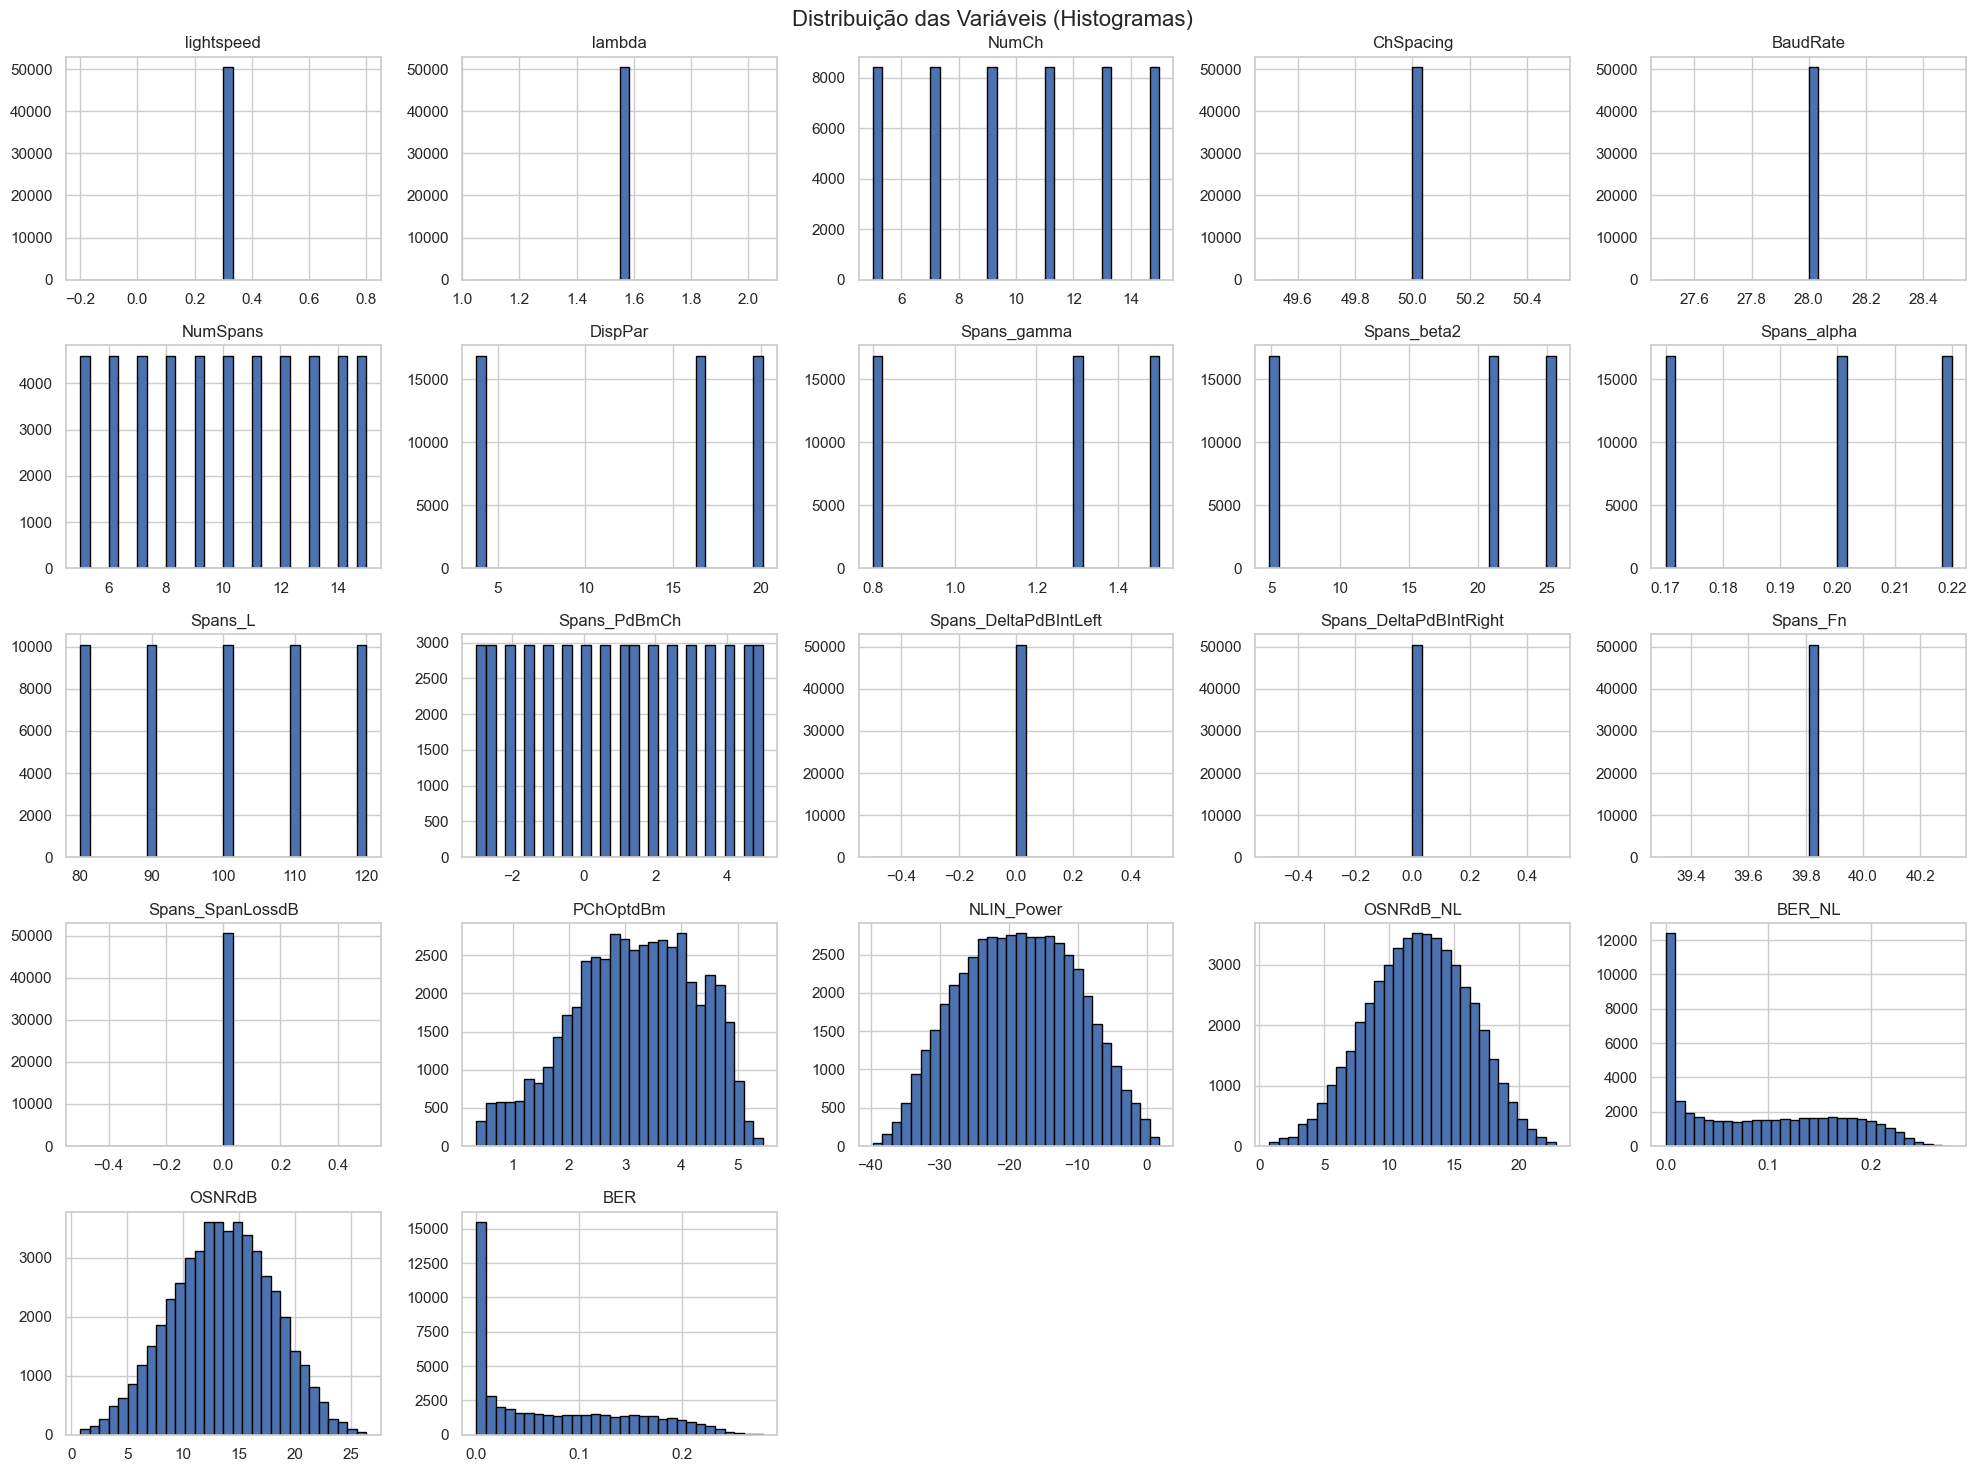

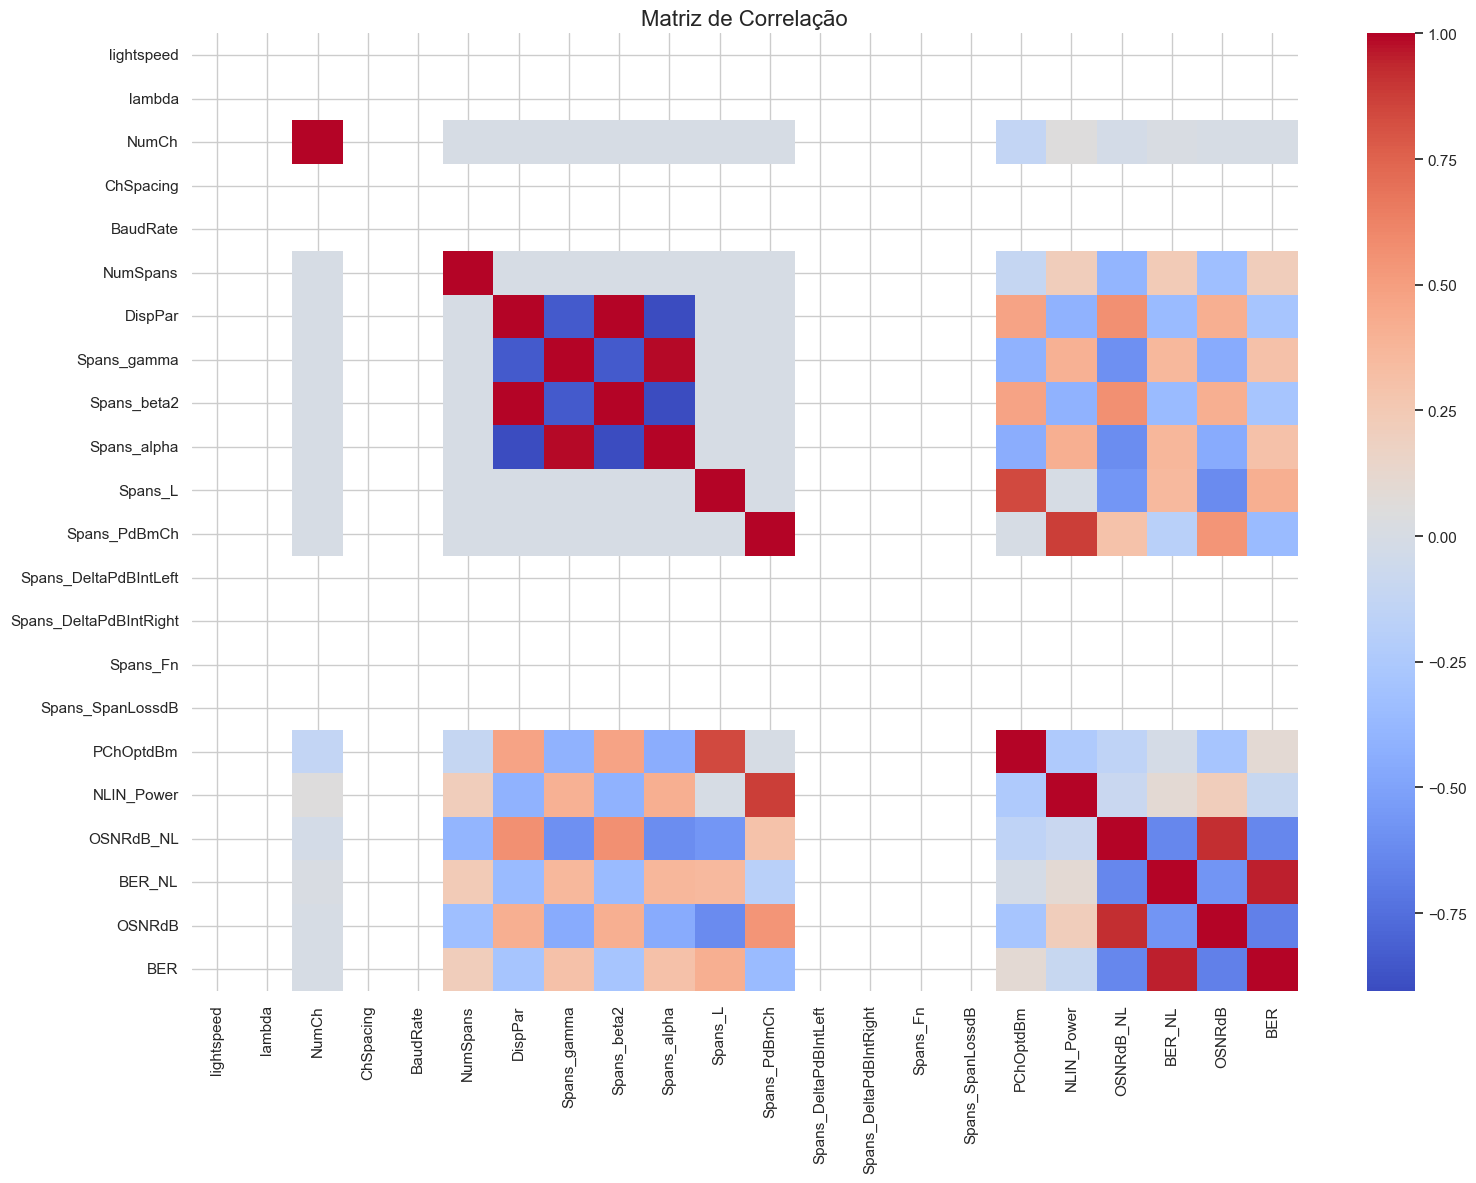

Correlação das features com o target (OSNRdB_NL):
OSNRdB_NL                 1.000000
OSNRdB                    0.924376
DispPar                   0.566067
Spans_beta2               0.566067
Spans_PdBmCh              0.300205
NumCh                    -0.022522
NLIN_Power               -0.086573
PChOptdBm                -0.148773
NumSpans                 -0.394130
Spans_L                  -0.565955
Spans_gamma              -0.597724
Spans_alpha              -0.607532
BER_NL                   -0.640581
BER                      -0.641684
lightspeed                     NaN
lambda                         NaN
ChSpacing                      NaN
BaudRate                       NaN
Spans_DeltaPdBIntLeft          NaN
Spans_DeltaPdBIntRight         NaN
Spans_Fn                       NaN
Spans_SpanLossdB               NaN
Name: OSNRdB_NL, dtype: float64


In [5]:
# Análise Exploratória de Dados (EDA) - Parte 2 (Visualizações)
# Distribuições das Variáveis (Histogramas)
df.hist(bins=30, figsize=(20, 15), edgecolor='black')
plt.suptitle("Distribuição das Variáveis (Histogramas)", fontsize=16)
plt.tight_layout()
plt.show()

# Heatmap: Matriz de Correlação
# Selecionamos de antemão os parâmetros numéricos para não gerar avisos do seaborn
numeric_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 12))
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação", fontsize=16)
plt.tight_layout()
plt.show()

# Ver correlação descendente e isolada apenas do alvo OSNRdB_NL
if 'OSNRdB_NL' in correlation_matrix.columns:
    print("Correlação das features com o target (OSNRdB_NL):")
    print(correlation_matrix['OSNRdB_NL'].sort_values(ascending=False))

### Pré-Processamento
* **Mapeamento de Modulação:** As modulações `Spans_ModFormatCh` foram mapeadas proporções numéricas.
* **Remoção de Colunas sem Variância:** Features que não variam no conjunto de dados não agregam informação e podem tornar o treino ineficiente.
* **Prevenção de Data Leakage (Fuga de Dados):** As features relacionadas a saídas e cálculos do simulador (como `PChOptdBm`, `OSNRdB`, `BER`, etc.) foram droppadas para evitar previsões 'trapaceadas' na variável alvo.
* **Normalização (Standard Scaler):** Redes Neurais e SVMs são sensíveis à magnitude dos dados. Normalizar as distribuições garante convergência mais rápida do Loss.

In [6]:
# Pré-processamento e Feature Engineering
print(f"Dimensões do dataframe inicial: {df.shape}")

# Mapeamento da Modulação ('Spans_ModFormatCh')
modulation_mapping = {
    'DP-QPSK': 0.25,
    'DP-16QAM': 0.125,
    'DP-64QAM': 0.083333
}

if 'Spans_ModFormatCh' in df.columns:
    df['Spans_ModFormatCh'] = df['Spans_ModFormatCh'].map(modulation_mapping)
    print("Mapeamento de Modulação numérico concluído.")

# Feature Selection: Descartar colunas constantes
nunique = df.nunique()
cols_to_drop_variance = nunique[nunique <= 1].index
if len(cols_to_drop_variance) > 0:
    df = df.drop(columns=cols_to_drop_variance)
    print(f"Colunas descartadas por falta de variação ({len(cols_to_drop_variance)}): {list(cols_to_drop_variance)}")

# Definição do Alvo e Descartes
# Nosso target é 'OSNRdB_NL'.
cols_to_discard = ['PChOptdBm', 'NLIN_Power', 'BER_NL', 'OSNRdB', 'BER']
columns_present_to_drop = [c for c in cols_to_discard if c in df.columns]

y = df['OSNRdB_NL']
X = df.drop(columns=columns_present_to_drop + ['OSNRdB_NL'])

# Traduzir as variáveis categóricas restantes que hajam sobre o dataset para numéricas (One-Hot Formatting)
X = pd.get_dummies(X, drop_first=True)

# Split Train/Test & Standardization Scaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Formato de Input p/ Treino (X, y): {X_train.shape}, {y_train.shape}")
print(f"Formato de Input p/ Teste  (X, y): {X_test.shape}, {y_test.shape}")

Dimensões do dataframe inicial: (50488, 25)
Mapeamento de Modulação numérico concluído.
Colunas descartadas por falta de variação (8): ['lightspeed', 'lambda', 'ChSpacing', 'BaudRate', 'Spans_DeltaPdBIntLeft', 'Spans_DeltaPdBIntRight', 'Spans_Fn', 'Spans_SpanLossdB']
Formato de Input p/ Treino (X, y): (40390, 13), (40390,)
Formato de Input p/ Teste  (X, y): (10098, 13), (10098,)


In [7]:
X_train.columns

Index(['NumCh', 'NumSpans', 'DispPar', 'Spans_gamma', 'Spans_beta2',
       'Spans_alpha', 'Spans_L', 'Spans_PdBmCh', 'Spans_ModFormatCh',
       'Spans_ModFormatIntLeft_DP-64QAM', 'Spans_ModFormatIntLeft_DP-QPSK',
       'Spans_ModFormatIntRight_DP-64QAM', 'Spans_ModFormatIntRight_DP-QPSK'],
      dtype='str')

#### Normalização das Features

In [8]:
# Standardization Scaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Formato de Input para Treino (X, y): {X_train_scaled.shape}, {y_train.shape}")
print(f"Formato de Input para Teste  (X, y): {X_test_scaled.shape}, {y_test.shape}")

Formato de Input para Treino (X, y): (40390, 13), (40390,)
Formato de Input para Teste  (X, y): (10098, 13), (10098,)


### Support Vector Machine (SVR)

* **Regressão com Kernel RBF:** O ambiente de simulações em fibra ótica apresenta bastante ruído (ex. interações não-lineares da Modulação). O *Radial Basis Function (RBF) Kernel* adapta-se projetando este input multidimensional em projeções curvadas para um Fit de excelência das instâncias de treino.

In [9]:
svm_model = SVR(kernel='rbf', C=1.0, epsilon=0.05)

# Configuração da Validação Cruzada
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error'
}

# O cross_val_score já treina e valida o modelo 5 vezes automaticamente
cv_results = cross_validate(svm_model, X_train_scaled, y_train, cv=kf, scoring=scoring, verbose=1)



[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  2.1min finished


In [10]:
print("  ESTABILIDADE (CROSS-VALIDATION)")
print(f"R² Médio         : {np.mean(cv_results['test_r2']):.4f} (+/- {np.std(cv_results['test_r2']):.4f})")
print(f"MAE Médio        : {-np.mean(cv_results['test_mae']):.4f} dB")
print(f"MSE Médio        : {-np.mean(cv_results['test_mse']):.4f}")
print(f"RMSE Médio: {np.mean(np.sqrt(-cv_results['test_mse'])):.4f} dB")

  ESTABILIDADE (CROSS-VALIDATION)
R² Médio         : 0.9998 (+/- 0.0000)
MAE Médio        : 0.0377 dB
MSE Médio        : 0.0025
RMSE Médio: 0.0498 dB


In [11]:
# Treino final e Previsão no conjunto de teste
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# Cálculo das métricas pontuais no conjunto de teste
r2_svm = r2_score(y_test, y_pred_svm)
mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)


print("  DESEMPENHO NO TESTE (HOLD-OUT)")
print(f"R² (Determinação)       : {r2_svm:.4f}")
print(f"MAE (Erro Absoluto)     : {mae_svm:.4f} dB")
print(f"MSE (Erro Quadrático)   : {mse_svm:.4f}")
print(f"RMSE (Raiz do Quadrático): {rmse_svm:.4f} dB")

  DESEMPENHO NO TESTE (HOLD-OUT)
R² (Determinação)       : 0.9999
MAE (Erro Absoluto)     : 0.0355 dB
MSE (Erro Quadrático)   : 0.0021
RMSE (Raiz do Quadrático): 0.0456 dB


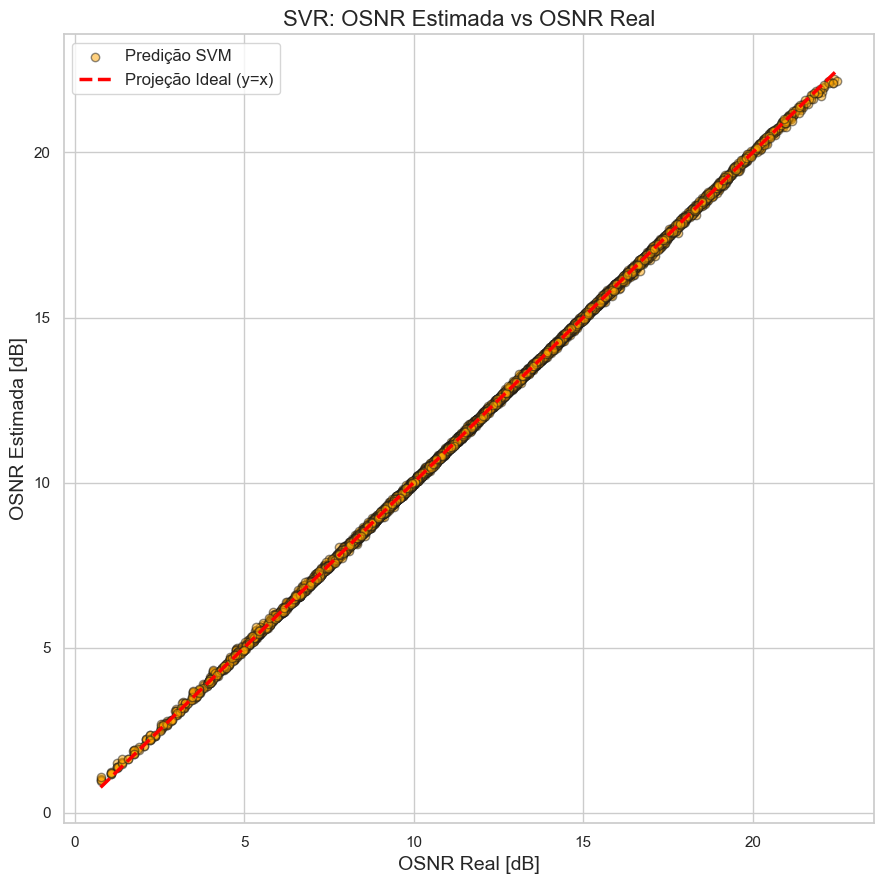

In [12]:
# Scatter Plot para os resultados do SVM (SVR)
plt.figure(figsize=(9, 9))
plt.scatter(y_test, y_pred_svm, alpha=0.5, label='Predição SVM', color='orange', edgecolor='k')

lim_min = min(y_test.min(), y_pred_svm.min())
lim_max = max(y_test.max(), y_pred_svm.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], color='red', linestyle='--', linewidth=2.5, label='Projeção Ideal (y=x)')

plt.title('SVR: OSNR Estimada vs OSNR Real', fontsize=16)
plt.xlabel('OSNR Real [dB]', fontsize=14)
plt.ylabel('OSNR Estimada [dB]', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

### Arquitetura da Rede Neural (ANN)
* **Arquitetura Base:** 2 camadas ocultas de 64 neurónios, conferindo profundidade ideal para captar padrões QoT sem overfit imediato.

* **Funções de Ativação Combinadas:** `ReLU` na 1ª camada para evitar decaimento do gradiente, e `Sigmoid` na 2ª para mapas não lineares suaves. A camada de saída é `Linear` porque a meta de previsão é contínua (Regressão).

* **Optimizador AdamW:** O otimizador `AdamW` melhora a generalização aplicando um Decaimento de Pesos independente.

* **Early Stopping:** Implementado para monitorar a perda de validação (val_loss) com uma paciência definida (ex: 10 épocas). Esse mecanismo garante que o treinamento cesse assim que o modelo parar de aprender padrões generalizáveis e comece a "decorar".

### Validação Cruzada (Cross-Validation) - ANN
Realizando validação cruzada k-fold para obter as projeções out-of-fold (Curva Real x Estimada).

In [13]:
def create_ann_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(64, activation='sigmoid'),
        Dense(1, activation='linear')
    ])
    optimizer = AdamW(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mse', 'mae'])
    return model


kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = []
cv_mae = []
cv_mse = []
cv_rmse = []

print("Iniciando Validação Cruzada (5 Folds) para a Rede Neural...")

# Variável para armazenar as previsões out-of-fold
oof_preds = np.zeros_like(y_train)

# Caso y_train seja um DataFrame/Series do pandas ou numpy array
y_train_arr = y_train.values if hasattr(y_train, 'values') else y_train

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
    print(f"Treinando Fold {fold+1}...")
    X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_fold_train, y_fold_val = y_train_arr[train_idx], y_train_arr[val_idx]
    
    model_cv = create_ann_model()
    
    early_stop_cv = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    model_cv.fit(
        X_fold_train,
        y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=200,
        callbacks=[early_stop_cv],
        batch_size=64,
        verbose=0
    )
    
    # Previsão no fold de validação
    y_fold_pred = model_cv.predict(X_fold_val).flatten()
    oof_preds[val_idx] = y_fold_pred
    
    r2 = r2_score(y_fold_val, y_fold_pred)
    mae = mean_absolute_error(y_fold_val, y_fold_pred)
    mse = mean_squared_error(y_fold_val, y_fold_pred)
    rmse = np.sqrt(mse)
    
    cv_r2.append(r2)
    cv_mae.append(mae)
    cv_mse.append(mse)
    cv_rmse.append(rmse)

print("\n=== ESTABILIDADE ANN (CROSS-VALIDATION) ===")
print(f"R² Médio         : {np.mean(cv_r2):.4f} (+/- {np.std(cv_r2):.4f})")
print(f"MAE Médio        : {np.mean(cv_mae):.4f} dB")
print(f"MSE Médio        : {np.mean(cv_mse):.4f}")
print(f"RMSE Médio       : {np.mean(cv_rmse):.4f} dB")

Iniciando Validação Cruzada (5 Folds) para a Rede Neural...
Treinando Fold 1...


C:\Users\Victor\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step
Treinando Fold 2...


C:\Users\Victor\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 606us/step
Treinando Fold 3...


...

253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step
Treinando Fold 4...


C:\Users\Victor\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step
Treinando Fold 5...


C:\Users\Victor\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step

=== ESTABILIDADE ANN (CROSS-VALIDATION) ===
R² Médio         : 0.9999 (+/- 0.0000)
MAE Médio        : 0.0287 dB
MSE Médio        : 0.0015
RMSE Médio       : 0.0386 dB


C:\Users\Victor\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

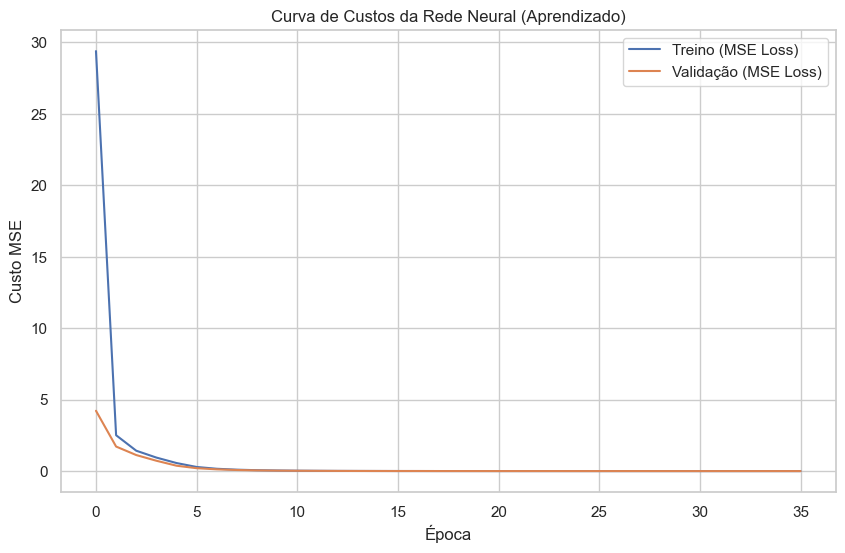

In [14]:
# Arquitetura do Modelo ANN Keras
model = create_ann_model()

# Parametrização Otimizador, Learning Rate e Compilação
optimizer = AdamW(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mse', 'mae'])

model.summary()


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Inicialização do Treinamento
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.3,
    epochs=200,
    callbacks=[early_stop],
    batch_size=64,
    verbose=0
)

plt.figure()
plt.plot(history.history['loss'], label='Treino (MSE Loss)')
plt.plot(history.history['val_loss'], label='Validação (MSE Loss)')
plt.title('Curva de Custos da Rede Neural (Aprendizado)')
plt.xlabel('Época')
plt.ylabel('Custo MSE')
plt.legend()
plt.show()

316/316 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step
=== Desempenho ===
Coeficiente R² de Determinação : 0.9999
MAE (Erro Médio Absoluto)    : 0.0304 dB
MSE (Erro Quadrádico Médio)    : 0.0016
RMSE (Raiz do Erro Quad.)      : 0.0404 dB


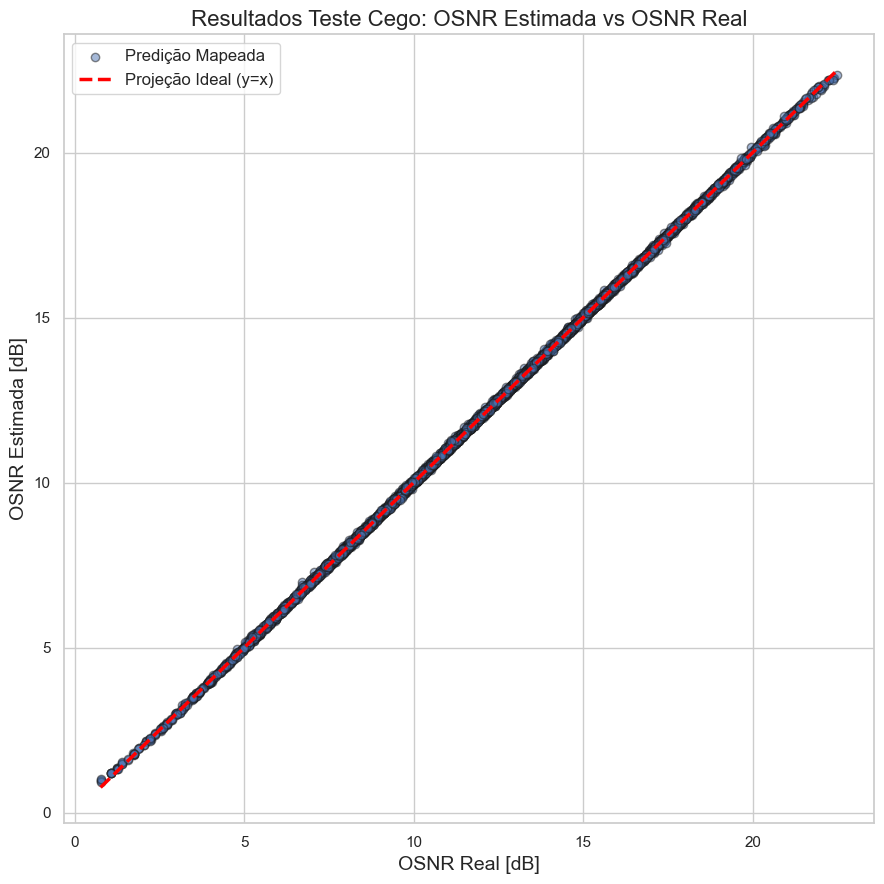

In [15]:
# Predições
y_pred = model.predict(X_test_scaled).flatten()

# Cálculo estatístico das métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=== Desempenho ===")
print(f"Coeficiente R² de Determinação : {r2:.4f}")
print(f"MAE (Erro Médio Absoluto)    : {mae:.4f} dB")
print(f"MSE (Erro Quadrádico Médio)    : {mse:.4f}")
print(f"RMSE (Raiz do Erro Quad.)      : {rmse:.4f} dB")

# Gráfico de Dispersão (Scatter Plot): Previsto vs Real com a Retilínea de Erro
plt.figure(figsize=(9, 9))
plt.scatter(y_test, y_pred, alpha=0.5, label='Predição Mapeada', edgecolor='k')

# Interseção Perfeita 'y = x' (Linha Vermelha de Idealidade descrita no Paper)
lim_min = min(y_test.min(), y_pred.min())
lim_max = max(y_test.max(), y_pred.max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], color='red', linestyle='--', linewidth=2.5, label='Projeção Ideal (y=x)')

plt.title('Resultados Teste Cego: OSNR Estimada vs OSNR Real', fontsize=16)
plt.xlabel('OSNR Real [dB]', fontsize=14)
plt.ylabel('OSNR Estimada [dB]', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()